In [2]:
import warnings
warnings.filterwarnings("ignore")
 
import sys, os
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler

In [3]:
print("=" * 60)
print("  2026 F1 Miami GP – RACE PREDICTION MODEL")
print("  Miami International Autodrome  | 01 - 03 May, 2026")
print("=" * 60)

  2026 F1 Miami GP – RACE PREDICTION MODEL
  Miami International Autodrome  | 01 - 03 May, 2026


In [4]:
os.makedirs("cache", exist_ok=True)
fastf1.Cache.enable_cache("cache")

In [5]:
import os
print(os.getcwd())                          # where Python thinks you are right now
print(os.listdir(os.getcwd()))     

/Users/jinhayoon/Desktop/F1 Prediction/F12026_Prediction
['.Rhistory', 'F12026SuzukaGP.ipynb', '.DS_Store', 'accuracy_log.csv', 'cache', 'shared_config.py', 'F12026SHGP.ipynb', '__pycache__', 'README.md', 'figures', '.gitattributes', 'F12026AusGP.ipynb', '.git', 'F12026MiamiGP.ipynb']


In [ ]:
notebook_dir = os.getcwd()
sys.path.insert(0, notebook_dir)

from shared_config import (
    DRIVER_TEAMS_2026,
    ROOKIES_2026,
    TEAM_COLORS,
    DNF, DNS,
    R01_AUS,
    R02_CHN,
    R03_JPN,
    calculate_team_tiers,
    calculate_quali_gap,
    compute_season_form,
    tune_form_weights,
    position_to_number
)


RACES_BEFORE_MIAMI = [("R01", "Australia", R01_AUS),
                      ("R02", "China", R02_CHN),
                      ("R03", "Japan", R03_JPN)] 

print(f" {len(DRIVER_TEAMS_2026)} drivers | "
      f"{len(RACES_BEFORE_MIAMI)} prior races. ")

print(f" Prior races: {[r[1] for r in RACES_BEFORE_MIAMI]}")

 22 drivers | 3 prior races. 
 Prior races: ['Australia', 'China', 'Japan']


In [7]:
TEAM_TIERS_BEFORE_MIAMI = calculate_team_tiers(
    races_so_far=RACES_BEFORE_MIAMI,
    driver_teams=DRIVER_TEAMS_2026
)

QUALI_GAP = calculate_quali_gap(
    races_completed = RACES_BEFORE_MIAMI,
    driver_teams=DRIVER_TEAMS_2026,
    fastf1_module=fastf1,
)

print(f" TEAM TIERS : {TEAM_TIERS_BEFORE_MIAMI}")
print(f"QUALI GAP: {QUALI_GAP}")


core           INFO 	Loading data for Australian Grand Prix - Qualifying [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 18
core        WARNING 	No lap data for driver 55
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 18)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 55)
core           INFO 	Finished loading data for 22 drivers: ['63', '12', '6', '16', '81', '1', '44', '30', '41', '5', '27', '87', '31', '10', '23', '43', '14', '11', '77', '18', '3', '55']
core           INFO 	Loadi

 [quali_gap] Australia: pole 78.518s| 19 drivers loaded


core           INFO 	Finished loading data for 22 drivers: ['12', '63', '44', '16', '81', '1', '10', '3', '6', '87', '27', '43', '31', '30', '41', '5', '55', '23', '14', '77', '18', '11']
core           INFO 	Loading data for Japanese Grand Prix - Qualifying [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


 [quali_gap] China: pole 92.064s| 22 drivers loaded


core           INFO 	Finished loading data for 22 drivers: ['12', '63', '81', '16', '1', '44', '10', '6', '5', '41', '3', '31', '27', '30', '43', '55', '23', '87', '11', '77', '14', '18']


 [quali_gap] Japan: pole 88.778s| 22 drivers loaded
 TEAM TIERS : {'Mercedes': 1.0, 'Ferrari': 2.449, 'McLaren': 3.866, 'Haas': 4.339, 'Alpine': 4.37, 'Red Bull': 4.433, 'Racing Bulls': 4.496, 'Williams': 4.874, 'Cadillac': 4.906, 'Audi': 4.937, 'Aston Martin': 5.0}
QUALI GAP: {'Haas': 2.651, 'Cadillac': 4.948, 'Williams': 3.341, 'Audi': 2.513, 'McLaren': 1.507, 'Aston Martin': 5.0, 'Ferrari': 1.581, 'Red Bull': 2.007, 'Alpine': 2.554, 'Mercedes': 1.0, 'Racing Bulls': 2.573}


#  Rolling Season Form
how well a driver has been performing recently, calculated fresh before each race using only the results that have actually happened so far

- For each driver, take their finishing positions in all races so far and compute a weighted average. more recent races count for more.

In [8]:
FORM_MIA = compute_season_form(RACES_BEFORE_MIAMI, list(DRIVER_TEAMS_2026.keys()))

print("📊 Season form going INTO Miami (lower = better recent performance):")
for drv, score in sorted(FORM_MIA.items(), key=lambda x: x[1]):
    team = DRIVER_TEAMS_2026[drv]
    bar  = "█" * int(score / 2)
    print(f"  {drv:4s} ({team:15s}): {score:5.1f}  {bar}")

📊 Season form going INTO Miami (lower = better recent performance):
  ANT  (Mercedes       ):   1.2  
  RUS  (Mercedes       ):   2.6  █
  LEC  (Ferrari        ):   3.3  █
  HAM  (Ferrari        ):   4.5  ██
  GAS  (Alpine         ):   7.4  ███
  LAW  (Racing Bulls   ):   9.3  ████
  OCO  (Haas           ):  11.6  █████
  LIN  (Racing Bulls   ):  11.9  █████
  BEA  (Haas           ):  12.0  █████
  SAI  (Williams       ):  12.6  ██████
  COL  (Alpine         ):  13.5  ██████
  PER  (Cadillac       ):  16.1  ████████
  HAD  (Red Bull       ):  30.6  ███████████████
  HUL  (Audi           ):  31.4  ███████████████
  BOT  (Cadillac       ):  35.3  █████████████████
  NOR  (McLaren        ):  36.3  ██████████████████
  VER  (Red Bull       ):  37.5  ██████████████████
  BOR  (Audi           ):  40.7  ████████████████████
  ALB  (Williams       ):  44.5  ██████████████████████
  PIA  (McLaren        ):  56.8  ████████████████████████████
  ALO  (Aston Martin   ):  63.2  ████████████████████

In [9]:
# load historical Miami GP data (2022-2025)

def get_clean_race_pace(session):
    """
    return median lap time (seconds) per driver, green flag laps only.
    exclude pit laps, safety car laps, null lap time
    """

    laps = session.laps
    clean = laps[
        laps["LapTime"].notna() &
        laps["PitInTime"].isna() &
        laps["PitOutTime"].isna() &
        (laps["TrackStatus"] == "1")
    ].copy()
    clean["LapSeconds"] = clean["LapTime"].dt.total_seconds()
    return (clean.groupby("Driver")["LapSeconds"]
            .median().reset_index()
            .rename(columns={"LapSeconds": "RacePace"}))

def load_miami_race(year):
    print(f" [{year}] Miami GP...")
    sess = fastf1.get_session(year, "Miami", "R")
    sess.load(telemetry=False, weather=True, messages=False)
    res = sess.results[["Abbreviation", "GridPosition", "Position", "Status"]].copy()
    res = res.rename(columns={"Abbreviation": "Driver"})
    dnf_mask = res["Position"].isna()
    n_fin = (~dnf_mask).sum()
    res.loc[dnf_mask, "Position"] = list(range(n_fin + 1, n_fin + 1 + dnf_mask.sum()))
    res["IsDNF"] = dnf_mask
    res.loc[res["GridPosition"] == 0, "GridPosition"] = 22
    pace = get_clean_race_pace(sess)
    df = res.merge(pace, on="Driver", how="left")
    df["RaceAirTemp"] = sess.weather_data["AirTemp"].mean()
    df["Year"] = year
    return df

print("⏳ Loading historical Miami GP data (2022–2025)...")
hist_frames = []
for yr in [2022, 2023, 2024, 2025]:
    try:
        hist_frames.append(load_miami_race(yr))
    except Exception as e:
        print(f"  ⚠️  {yr} failed: {e}")

historical = pd.concat(hist_frames, ignore_index=True)
print(f"\n✅ Historical data: {len(historical)} rows | "
      f"{historical['Year'].nunique()} seasons")

core           INFO 	Loading data for Miami Grand Prix - Race [v3.8.1]


req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


⏳ Loading historical Miami GP data (2022–2025)...
 [2022] Miami GP...


req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '55', '11', '63', '44', '77', '31', '23', '18', '14', '22', '3', '6', '47', '20', '5', '10', '4', '24']
core           INFO 	Loading data for Miami Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


 [2023] Miami GP...


...

 [2024] Miami GP...


req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 20 drivers: ['4', '1', '16', '11', '55', '44', '22', '63', '14', '31', '27', '10', '81', '24', '3', '77', '18', '23', '20', '2']
core           INFO 	Loading data for Miami Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '6'
core        WARNING 	Fixed incorrect tyre stint information for driver '31'
core        WARNING 	Fixed incorrect tyre stint information for driver '18'
core       

 [2025] Miami GP...


req            INFO 	Using cached data for weather_data
core        WARNING 	Driver 81 completed the race distance 00:00.036000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['81', '4', '63', '1', '23', '12', '16', '44', '55', '22', '6', '31', '10', '27', '14', '18', '30', '5', '87', '7']



✅ Historical data: 80 rows | 4 seasons


feature engineering

In [10]:
# ── CIRCUIT SCORE: Weighted historical Miami finishing positions ────────────────
YEAR_WEIGHTS = {2022: 0.7, 2023: 0.9, 2024: 1.2, 2025: 1.5}
historical["YearWeight"] = historical["Year"].map(YEAR_WEIGHTS)

circuit_score_map = (
    historical.groupby("Driver")
    .apply(lambda g: np.average(g["Position"], weights=g["YearWeight"]))
    .to_dict()
)

historical["Team2026"] = historical["Driver"].map(DRIVER_TEAMS_2026)
team_avg = (historical.dropna(subset=["Team2026"])
            .groupby("Team2026")["Position"].mean().to_dict())

def get_circuit_score(drv):
    if drv in circuit_score_map:
        return circuit_score_map[drv]
    team = DRIVER_TEAMS_2026.get(drv)
    return team_avg.get(team, 12.0)

MIAMI_QUALI_2026 = [
    ("ANT",  1,  0.000), ("VER",  2,  0.166), ("LEC",  3,  0.345),
    ("NOR",  4,  0.385), ("RUS",  5,  0.399), ("HAM",  6,  0.521),
    ("PIA",  7,  0.702), ("COL",  8,  0.964), ("HAD",  9,  0.991),
    ("GAS", 10,  1.012), ("HUL", 11,  1.323), ("LAW", 12,  1.383),
    ("BEA", 13,  1.451), ("SAI", 14,  1.452), ("OCO", 15,  1.656),
    ("ALB", 16,  1.830), ("LIN", 17,  1.480), ("ALO", 18,  2.445),
    ("STR", 19,  2.511), ("BOT", 20,  2.976), ("PER", 21,  3.314),
    ("BOR", 22,  5.084),
]

try:
    q_sess = fastf1.get_session(2026, "Miami", "Q")
    q_sess.load(laps=False, telemetry=False, weather=True, messages=False)
    QUAL_TEMP = q_sess.weather_data["AirTemp"].mean()
    print(f"  FastF1 quali weather: {QUAL_TEMP:.1f}°C")
except:
    QUAL_TEMP = 28.0   # typical May Miami afternoon

RACE_TEMP    = QUAL_TEMP + 3.0    # race is hotter (afternoon start brought forward)
WEATHER_DELTA = RACE_TEMP - QUAL_TEMP

pred_df = pd.DataFrame(MIAMI_QUALI_2026, columns=["Driver", "GridPosition", "GapToPole"])
pred_df["Team"]         = pred_df["Driver"].map(DRIVER_TEAMS_2026)
pred_df["TeamTier"]     = pred_df["Team"].map(TEAM_TIERS_BEFORE_MIAMI)
pred_df["ERSAdapt"]     = pred_df["Team"].map(QUALI_GAP)
pred_df["CircuitScore"] = pred_df["Driver"].apply(get_circuit_score)
pred_df["SeasonForm"]   = pred_df["Driver"].map(FORM_MIA)
pred_df["IsRookie"]     = pred_df["Driver"].isin(ROOKIES_2026).astype(int)
pred_df["WeatherDelta"] = WEATHER_DELTA

print("✅ Miami 2026 prediction dataframe ready:")
print(pred_df[["Driver","Team","GridPosition","GapToPole","CircuitScore",
               "TeamTier","SeasonForm"]].to_string(index=False))


core           INFO 	Loading data for Miami Grand Prix - Qualifying [v3.8.1]
req            INFO 	Using cached data for session_info


req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 22 drivers: ['12', '3', '16', '1', '63', '44', '81', '43', '10', '27', '30', '87', '55', '31', '23', '41', '14', '18', '77', '11', '5', '6']


  FastF1 quali weather: 33.9°C
✅ Miami 2026 prediction dataframe ready:
Driver         Team  GridPosition  GapToPole  CircuitScore  TeamTier  SeasonForm
   ANT     Mercedes             1      0.000      6.000000     1.000    1.231884
   VER     Red Bull             2      0.166      2.325581     4.433   37.536232
   LEC      Ferrari             3      0.345      5.069767     2.449    3.333333
   NOR      McLaren             4      0.385      7.627907     3.866   36.333333
   RUS     Mercedes             5      0.399      4.930233     1.000    2.637681
   HAM      Ferrari             6      0.521      6.697674     2.449    4.536232
   PIA      McLaren             7      0.702      9.500000     3.866   56.826087
   COL       Alpine             8      0.964     12.750000     4.370   13.536232
   HAD     Red Bull             9      0.991     11.000000     4.433   30.608696
   GAS       Alpine            10      1.012     12.488372     4.370    7.362319
   HUL         Audi            11    

In [11]:
print(historical.columns.tolist())

['Driver', 'GridPosition', 'Position', 'Status', 'IsDNF', 'RacePace', 'RaceAirTemp', 'Year', 'YearWeight', 'Team2026']


In [ ]:
# tune form weights // hyperparameter tuning

FEATURES = ["GridPosition", "GapToPole", "CircuitScore",
            "TeamTier", "SeasonForm", "QualiGap", "IsRookie", "WeatherDelta"]

# Populate all feature columns on historical before running tuning
historical["Team2026"]     = historical["Driver"].map(DRIVER_TEAMS_2026)
historical["TeamTier"]     = historical["Team2026"].map(TEAM_TIERS_BEFORE_MIAMI).fillna(3.5)
historical["QualiGap"]     = 3.0          # pre-2026: neutral placeholder
historical["IsRookie"]     = 0
historical["WeatherDelta"] = historical["RaceAirTemp"] - historical["RaceAirTemp"].mean()
historical["CircuitScore"] = historical["Driver"].apply(get_circuit_score)
historical["SeasonForm"]   = 11.0         # placeholder — overwritten during tuning

# If historical lacks GapToPole (pre-2026 data), create a simple placeholder
if "GapToPole" not in historical.columns:
    historical["GapToPole"] = historical["GridPosition"].astype(float) - 1.0

print(f"⏳ Tuning recency weight ratio for Miami...")
print("   Searching: [1.0, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0]  (universal range)")
print()

tuning = tune_form_weights(
    historical_df=historical,
    features=FEATURES,
    target="Position",
    races_for_tuning=RACES_BEFORE_MIAMI,
    all_drivers=list(DRIVER_TEAMS_2026.keys()),
    # No high_candidates passed → uses universal default [1.0, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0]
    # No low_candidates passed  → fixed at [1.0]
    n_folds=5,
    verbose=True,
)

BEST_LOW  = tuning["best_low"]
BEST_HIGH = tuning["best_high"]

# Now compute the final form scores using the tuned ratio
FORM_MIA = compute_season_form(
    races_available=RACES_BEFORE_MIAMI,
    all_drivers=list(DRIVER_TEAMS_2026.keys()),
    low_weight=BEST_LOW,
    high_weight=BEST_HIGH,
)

print(f"\n📊 Season form going into Miami (tuned weights, lower = better):")
for drv, sc in sorted(FORM_MIA.items(), key=lambda x: x[1])[:8]:
    bar = "█" * max(1, int((22 - sc) / 2))
    print(f"  {drv:4s} ({DRIVER_TEAMS_2026[drv]:15s}): {sc:5.2f}  {bar}")


⏳ Tuning recency weight ratio for Miami...
   Searching: [1.0, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0]  (universal range)

Grid search: 1 low × 7 high = 6 valid combinations | 5-fold CV
   Low    High    Mean MAE     Std MAE
────────────────────────────────────────
  1.00    1.25      2.8528      0.4566
  1.00    1.50      2.8639      0.4576
  1.00    1.75      2.8705      0.4612
  1.00    2.00      2.8688      0.4628
  1.00    2.50      2.8811      0.4604
  1.00    3.00      2.8958      0.4827

✅ Best ratio: 1.25x  (most recent race counts 1.25× the oldest)
   Cross-validated MAE: 2.8528 ± 0.4566

📐 MAE spread across all ratios tested: 0.0429 positions
   → Spread is tiny. The ratio barely affects predictions.
   → Justification: use ratio=1.0 (equal weights) as the
     simplest defensible choice. Form weighting does not
     meaningfully improve the model for this circuit.

Full results (sorted best → worst):
    Ratio    Mean MAE     Std MAE
     1.25      2.8528      0.4566  ← best
     1

In [14]:
# ── SPREAD ANALYSIS: how much does the ratio actually matter? ─────────────────
all_results = tuning["all_results"]   # sorted best → worst
mae_spread  = tuning["mae_spread"]
best_ratio  = tuning["best_high"]

print("=" * 55)
print(f"  RATIO JUSTIFICATION — Miami")
print("=" * 55)
print(f"  Winning ratio:    {best_ratio:.2f}x")
print(f"  Best CV MAE:      {tuning['best_mae']:.4f} positions")
print(f"  Worst CV MAE:     {all_results[-1][2]:.4f} positions")
print(f"  MAE spread:       {mae_spread:.4f} positions")
print()

if mae_spread < 0.1:
    verdict = "WEAK SIGNAL"
    explanation = (
        "The ratio barely affects predictions for this circuit.\n"
        "  All ratios produce nearly identical MAE.\n"
        "  The simplest justification: use ratio=1.0 (equal weights)\n"
        "  and note that form weighting does not improve this model."
    )
elif mae_spread < 0.3:
    verdict = "MODERATE SIGNAL"
    explanation = (
        f"  The winning ratio ({best_ratio:.2f}) is a reasonable choice.\n"
        f"  It reduced MAE by {mae_spread:.3f} positions vs the worst alternative.\n"
        f"  Justification: cross-validation on {circuit_label} historical data\n"
        f"  preferred ratio={best_ratio:.2f} over all other candidates tested."
    )
else:
    verdict = "STRONG SIGNAL"
    explanation = (
        f"  The winning ratio ({best_ratio:.2f}) is clearly better than alternatives.\n"
        f"  It reduced MAE by {mae_spread:.3f} positions — a meaningful improvement.\n"
        f"  Justification: the data strongly prefers this recency weighting.\n"
        f"  This finding is well supported by cross-validation evidence."
    )

print(f"  Verdict: {verdict}")
print(f"  {explanation}")
print()
print("  What to write in your README / present in an interview:")
print(f'  \"The recency weight ratio of {best_ratio:.2f} was selected by')
print(f'  cross-validated grid search on historical Miami GP data.')
if mae_spread < 0.1:
    print(f'  The MAE spread across all candidates was only {mae_spread:.3f}')
    print(f'  positions, indicating the ratio has minimal impact for this')
    print(f'  circuit. Equal weighting (ratio=1.0) is therefore used.\"')
else:
    print(f'  It produced a cross-validated MAE of {tuning["best_mae"]:.3f}')
    print(f'  positions, outperforming all other tested values by up to')
    print(f'  {mae_spread:.3f} positions.\"')


  RATIO JUSTIFICATION — Miami
  Winning ratio:    1.25x
  Best CV MAE:      2.8528 positions
  Worst CV MAE:     2.8958 positions
  MAE spread:       0.0429 positions

  Verdict: WEAK SIGNAL
  The ratio barely affects predictions for this circuit.
  All ratios produce nearly identical MAE.
  The simplest justification: use ratio=1.0 (equal weights)
  and note that form weighting does not improve this model.

  What to write in your README / present in an interview:
  "The recency weight ratio of 1.25 was selected by
  cross-validated grid search on historical Miami GP data.
  The MAE spread across all candidates was only 0.043
  positions, indicating the ratio has minimal impact for this
  circuit. Equal weighting (ratio=1.0) is therefore used."


training set and train model   

In [15]:
FEATURES = ["GridPosition", "GapToPole", "CircuitScore",
            "TeamTier", "SeasonForm", "ERSAdapt", "IsRookie", "WeatherDelta"]
TARGET = "Position"

historical["Team2026"] = historical["Driver"].map(DRIVER_TEAMS_2026)
historical["TeamTier"]    = historical["Team2026"].map(TEAM_TIERS_BEFORE_MIAMI).fillna(3.5)
historical["CircuitScore"]= historical["Driver"].apply(get_circuit_score)
historical["ERSAdapt"]    = 3.0          # pre-2026: neutral
historical["IsRookie"]    = 0
historical["SeasonForm"]  = historical["Driver"].apply(
    lambda d: FORM_MIA.get(d, 11.0))
historical["WeatherDelta"]= (historical["RaceAirTemp"]
                             - historical["RaceAirTemp"].mean())

# loading quali gaps for historical years
print("⏳ Loading historical Miami qualifying gaps...")
historical["GapToPole"] = np.nan
for yr in historical["Year"].unique():
    try:
        q = fastf1.get_session(yr, "Miami", "Q")
        q.load(laps=True, telemetry=False, weather=False, messages=False)
        best = q.laps.pick_quicklaps().groupby("Driver")["LapTime"].min()
        pole_s = best.min().total_seconds()
        gap_map = (best.dt.total_seconds() - pole_s).to_dict()
        mask = historical["Year"] == yr
        historical.loc[mask, "GapToPole"] = historical.loc[mask, "Driver"].map(gap_map)
        print(f"  [{yr}] pole: {pole_s:.3f}s")
    except Exception as e:
        print(f"  [{yr}] failed: {e}")
historical["GapToPole"].fillna(historical["GapToPole"].median(), inplace=True)




⏳ Loading historical Miami qualifying gaps...


core           INFO 	Loading data for Miami Grand Prix - Qualifying [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	D

  [2022] pole: 88.796s


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for timing_app_data. Loading data...
_api           INFO 	Fetching timing app data...
req            INFO 	Data has been written to

  [2023] pole: 86.814s


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for timing_app_data. Loading data...
_api           INFO 	Fetching timing app data...
req            INFO 	Data has been written to

  [2024] pole: 87.241s


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for timing_app_data. Loading data...
_api           INFO 	Fetching timing app data...
req            INFO 	Data has been written to

  [2025] pole: 86.204s


In [16]:
train_df = historical.dropna(subset=FEATURES + [TARGET]).copy()
X = train_df[FEATURES].values
y = train_df[TARGET].values


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [18]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)


In [20]:
print("\n Training Gradient Boosting Model...")
model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    min_samples_split=4,
    random_state=42
)
model.fit(X_train_s, y_train)



 Training Gradient Boosting Model...


GradientBoostingRegressor(learning_rate=0.05, max_depth=4, min_samples_split=4,
                          n_estimators=300, random_state=42, subsample=0.8)

In [21]:
mae_test = mean_absolute_error(y_test, model.predict(X_test_s))
print(f"Trained. Test-set MAE: {mae_test:.2f} positions")

# cross validation
cv_scores = cross_val_score(model, scaler.transform(X), y,
                            cv=5, scoring="neg_mean_absolute_error")
print(f" 5-fold CV MAE: {-cv_scores.mean():.2f} ± {cv_scores.std():.2f}")

# Feature importance: which features drive the model most?
fi = pd.DataFrame({"Feature": FEATURES,
                   "Importance": model.feature_importances_}
                 ).sort_values("Importance", ascending=False)
print("\n📊 Feature importances:")
for _, r in fi.iterrows():
    bar = "█" * int(r["Importance"] * 80)
    print(f"  {r['Feature']:15s}: {bar} ({r['Importance']:.3f})")


Trained. Test-set MAE: 2.78 positions
 5-fold CV MAE: 3.22 ± 0.94

📊 Feature importances:
  GapToPole      : ███████████████████████████████████████████ (0.548)
  CircuitScore   : ████████████████ (0.208)
  GridPosition   : ███████████ (0.147)
  SeasonForm     : ███ (0.041)
  TeamTier       : ██ (0.029)
  WeatherDelta   : ██ (0.026)
  ERSAdapt       :  (0.000)
  IsRookie       :  (0.000)


In [22]:
# ── PREDICT ───────────────────────────────────────────────────────────────────
X_pred = pred_df[FEATURES].values
X_pred_s = scaler.transform(X_pred)
pred_df["RawScore"] = model.predict(X_pred_s)

# At Miami (permanent circuit, reasonable overtaking) → 20% grid bias
GRID_WEIGHT = 0.20
pred_df["BlendedScore"] = ((1 - GRID_WEIGHT) * pred_df["RawScore"]
                           + GRID_WEIGHT * pred_df["GridPosition"])

# Small DNF risk nudge for known unreliable drivers/incidents this weekend
DNF_RISK = {"BOR": 0.5, "LIN": 0.3, "HAD": 0.2}
pred_df["DNFNudge"]    = pred_df["Driver"].map(DNF_RISK).fillna(0)
pred_df["FinalScore"]  = pred_df["BlendedScore"] + pred_df["DNFNudge"]
pred_df["PredictedPos"]= pred_df["FinalScore"].rank(method="first").astype(int)

result = pred_df.sort_values("PredictedPos")[
    ["PredictedPos","Driver","Team","GridPosition","GapToPole","FinalScore"]
].reset_index(drop=True)

print("=" * 65)
print("  🏁 PREDICTED CLASSIFICATION — 2026 Miami Grand Prix")
print("=" * 65)
for _, r in result.iterrows():
    medal = {1:"🥇",2:"🥈",3:"🥉"}.get(r["PredictedPos"], "  ")
    print(f"  {medal}{r['PredictedPos']:>3}. {r['Driver']:<5} {r['Team']:<16}"
          f" P{int(r['GridPosition']):<3} +{r['GapToPole']:.3f}s")


  🏁 PREDICTED CLASSIFICATION — 2026 Miami Grand Prix
  🥇  1. ANT   Mercedes         P1   +0.000s
  🥈  2. VER   Red Bull         P2   +0.166s
  🥉  3. NOR   McLaren          P4   +0.385s
      4. LEC   Ferrari          P3   +0.345s
      5. RUS   Mercedes         P5   +0.399s
      6. HAM   Ferrari          P6   +0.521s
      7. ALO   Aston Martin     P18  +2.445s
      8. HAD   Red Bull         P9   +0.991s
      9. PIA   McLaren          P7   +0.702s
     10. SAI   Williams         P14  +1.452s
     11. HUL   Audi             P11  +1.323s
     12. PER   Cadillac         P21  +3.314s
     13. STR   Aston Martin     P19  +2.511s
     14. ALB   Williams         P16  +1.830s
     15. GAS   Alpine           P10  +1.012s
     16. BOT   Cadillac         P20  +2.976s
     17. OCO   Haas             P15  +1.656s
     18. COL   Alpine           P8   +0.964s
     19. BOR   Audi             P22  +5.084s
     20. LAW   Racing Bulls     P12  +1.383s
     21. LIN   Racing Bulls     P17  +1.480s
     

📊 Prediction chart saved: miami_2026_prediction.png


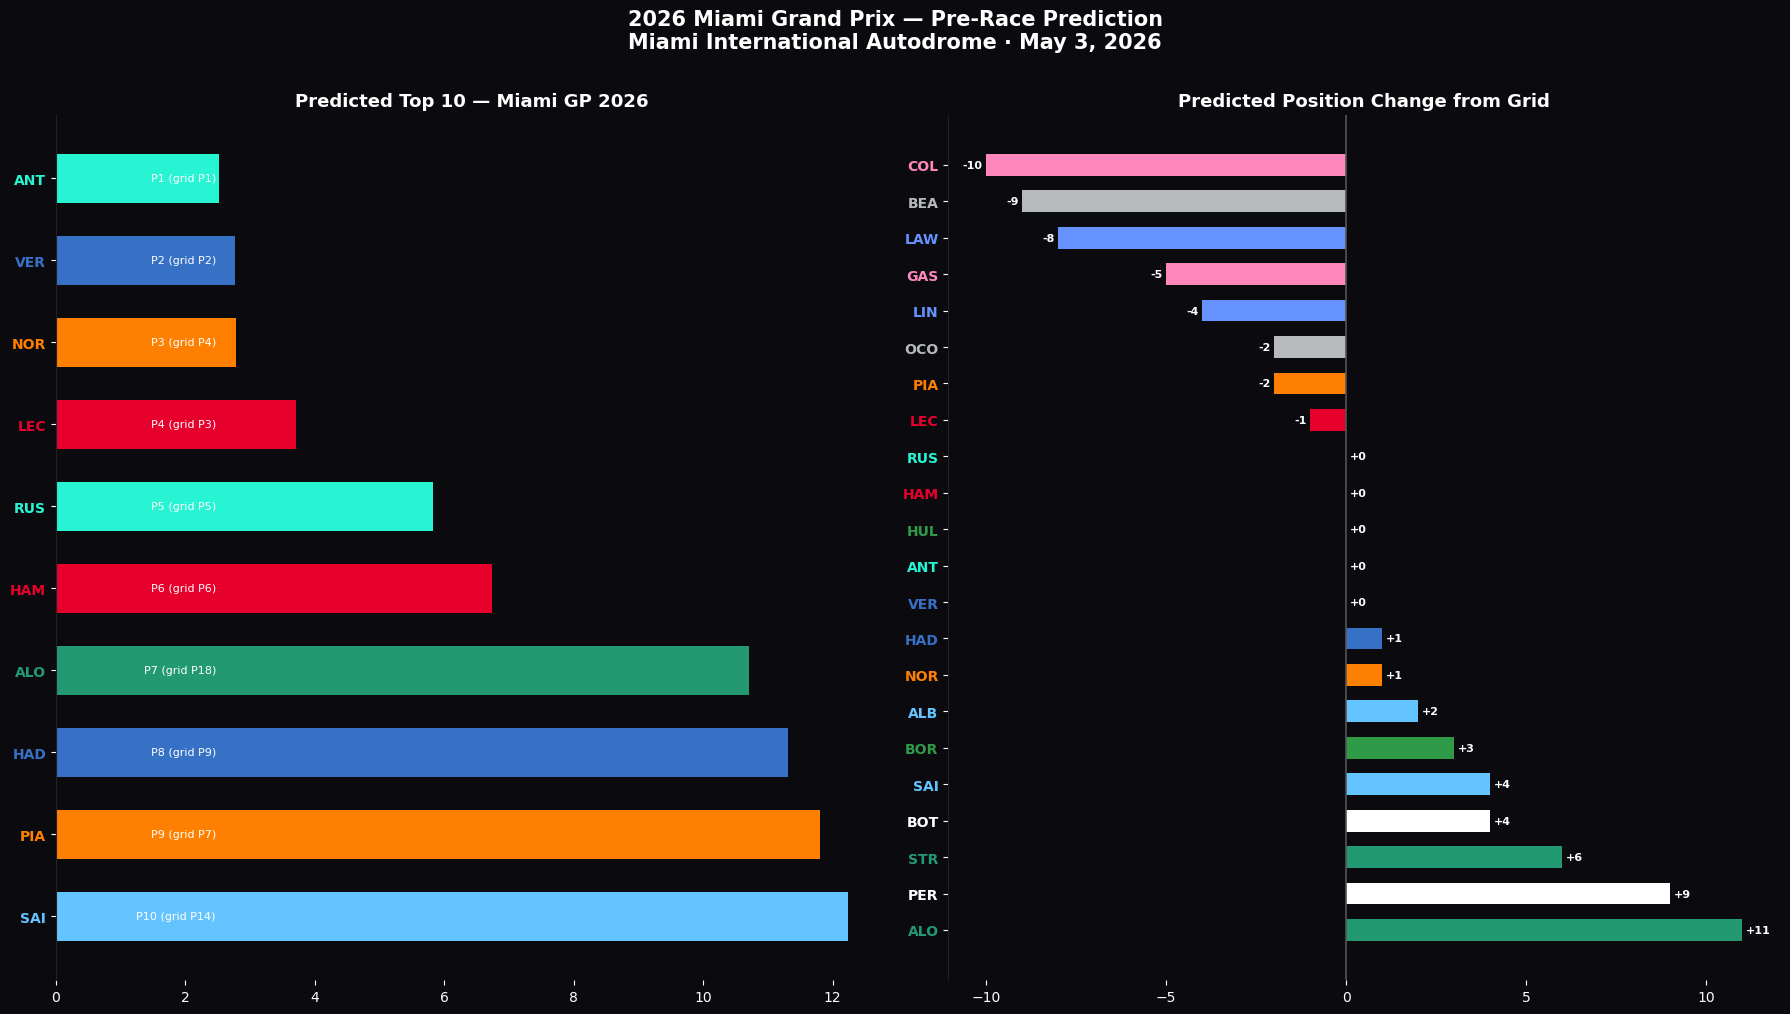

In [23]:
# ── VISUALISATION ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 10))
fig.patch.set_facecolor("#0a0a0f")

# LEFT: Top 10 prediction bar chart
ax1 = axes[0]
ax1.set_facecolor("#0a0a0f")
top10 = result.head(10).iloc[::-1]
colors = [TEAM_COLORS.get(t, "#888") for t in top10["Team"]]
ax1.barh(top10["Driver"], top10["FinalScore"], color=colors, height=0.6)
for i, (_, r) in enumerate(top10.iterrows()):
    ax1.text(min(top10["FinalScore"])*0.98, i,
             f"P{r['PredictedPos']} (grid P{int(r['GridPosition'])})",
             va="center", ha="right", color="white", fontsize=8)
ax1.set_title("Predicted Top 10 — Miami GP 2026", color="white", fontsize=13, fontweight="bold")
ax1.tick_params(colors="white"); ax1.set_facecolor("#0a0a0f")
for label in ax1.get_yticklabels():
    label.set_color(TEAM_COLORS.get(DRIVER_TEAMS_2026.get(label.get_text(),""),"white"))
    label.set_fontweight("bold")
ax1.spines[["top","right","bottom"]].set_visible(False)
ax1.spines["left"].set_color("#222")

# RIGHT: Position gain/loss chart
ax2 = axes[1]
ax2.set_facecolor("#0a0a0f")
result["Gain"] = result["GridPosition"] - result["PredictedPos"]
gain_df = result.sort_values("Gain", ascending=False)
g_colors = [TEAM_COLORS.get(DRIVER_TEAMS_2026.get(d,""),"#888") for d in gain_df["Driver"]]
bars = ax2.barh(gain_df["Driver"], gain_df["Gain"], color=g_colors, height=0.6)
for bar, g in zip(bars, gain_df["Gain"]):
    ax2.text(g + (0.1 if g>=0 else -0.1), bar.get_y()+bar.get_height()/2,
             f"{g:+d}", va="center", ha="left" if g>=0 else "right",
             color="white", fontsize=8, fontweight="bold")
ax2.axvline(0, color="#555", linewidth=1.2)
ax2.set_title("Predicted Position Change from Grid", color="white", fontsize=13, fontweight="bold")
ax2.tick_params(colors="white")
for label in ax2.get_yticklabels():
    label.set_color(TEAM_COLORS.get(DRIVER_TEAMS_2026.get(label.get_text(),""),"white"))
    label.set_fontweight("bold")
ax2.spines[["top","right","bottom"]].set_visible(False)
ax2.spines["left"].set_color("#222")

fig.suptitle("2026 Miami Grand Prix — Pre-Race Prediction\nMiami International Autodrome · May 3, 2026",
             color="white", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("miami_2026_prediction.png", dpi=180, bbox_inches="tight",
            facecolor=fig.get_facecolor())
print("📊 Prediction chart saved: miami_2026_prediction.png")
plt.show()


  POST-RACE EVALUATION — 2026 Miami Grand Prix
  Race MAE:          11.82 positions
  Winner correct:    ✅
  Podium accuracy:   2/3 drivers
  Points accuracy:   8/10 drivers

  Biggest misses (|error| ≥ 3 positions):
  HAD : predicted P8, actual P98  (underrated by 90 positions)
  GAS : predicted P15, actual P98  (underrated by 83 positions)
  BEA : predicted P22, actual P11  (overrated by 11 positions)
  COL : predicted P18, actual P7  (overrated by 11 positions)
  HUL : predicted P11, actual P20  (underrated by 9 positions)
  ALO : predicted P7, actual P15  (underrated by 8 positions)
  LIN : predicted P21, actual P14  (overrated by 7 positions)
  BOR : predicted P19, actual P12  (overrated by 7 positions)
  PIA : predicted P9, actual P3  (overrated by 6 positions)
  STR : predicted P13, actual P17  (underrated by 4 positions)
  OCO : predicted P17, actual P13  (overrated by 4 positions)
  ALB : predicted P14, actual P10  (overrated by 4 positions)
  PER : predicted P12, actual P16  

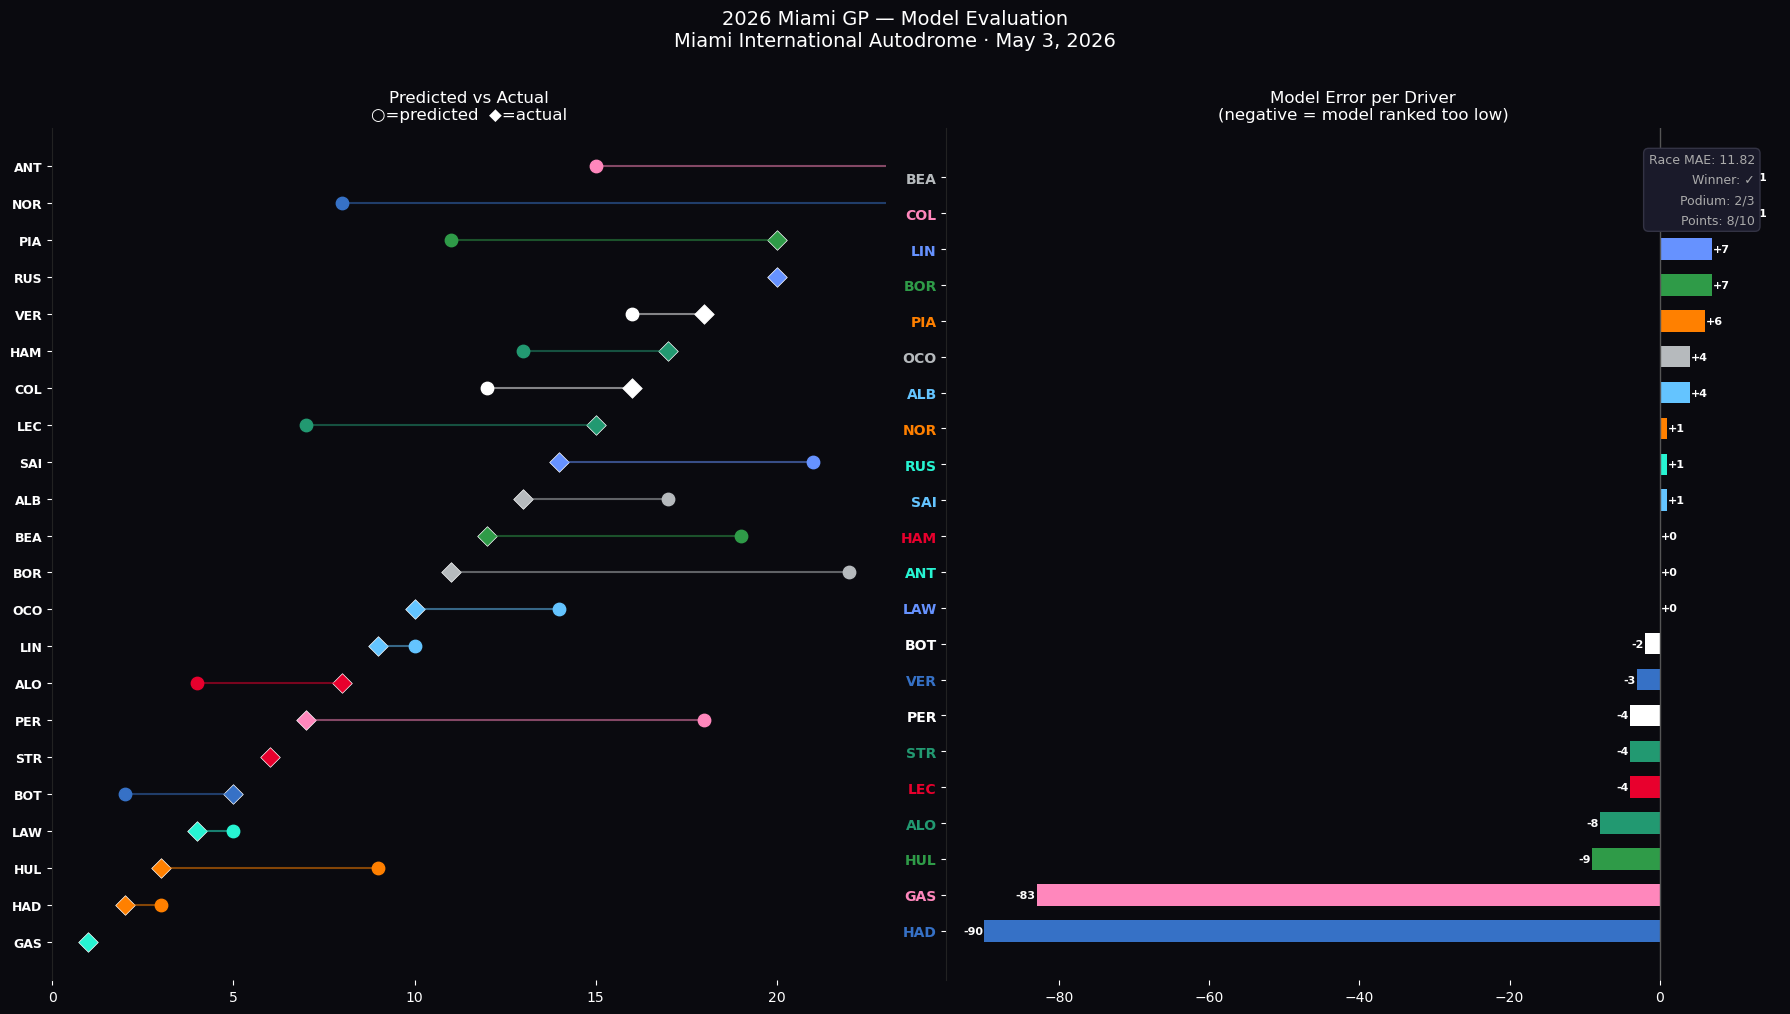

In [27]:
from shared_config import R04_MIA, position_to_number

ACTUAL = R04_MIA  # Miami actual results (post-penalty)

eval_df["ActualPos"] = eval_df["Driver"].map(ACTUAL)
eval_df = eval_df.dropna(subset=["ActualPos"])
eval_df["ActualPos"] = eval_df["ActualPos"].apply(position_to_number).astype(int)
eval_df["Error"]     = eval_df["PredictedPos"] - eval_df["ActualPos"]

race_mae     = mean_absolute_error(eval_df["ActualPos"], eval_df["PredictedPos"])
winner_ok    = eval_df[eval_df["ActualPos"]==1]["PredictedPos"].iloc[0] == 1
actual_pod   = set(eval_df[eval_df["ActualPos"]<=3]["Driver"])
pred_pod     = set(eval_df[eval_df["PredictedPos"]<=3]["Driver"])
pod_ok       = len(actual_pod & pred_pod)
pts_ok       = len(set(eval_df[eval_df["ActualPos"]<=10]["Driver"]) &
                   set(eval_df[eval_df["PredictedPos"]<=10]["Driver"]))

print("=" * 55)
print("  POST-RACE EVALUATION — 2026 Miami Grand Prix")
print("=" * 55)
print(f"  Race MAE:          {race_mae:.2f} positions")
print(f"  Winner correct:    {'✅' if winner_ok else '❌'}")
print(f"  Podium accuracy:   {pod_ok}/3 drivers")
print(f"  Points accuracy:   {pts_ok}/10 drivers")

# Biggest misses
big_miss = eval_df.reindex(eval_df["Error"].abs().sort_values(ascending=False).index)
print("\n  Biggest misses (|error| ≥ 3 positions):")
for _, r in big_miss[big_miss["Error"].abs()>=3].iterrows():
    dir_ = "overrated" if r["Error"]>0 else "underrated"
    print(f"  {r['Driver']:4s}: predicted P{r['PredictedPos']}, actual P{r['ActualPos']}  "
          f"({dir_} by {abs(r['Error'])} positions)")

# ── Evaluation visualisation (same dark theme) ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 10))
fig.patch.set_facecolor("#0a0a0f")

ax1 = axes[0]; ax1.set_facecolor("#0a0a0f")
e_sorted = eval_df.sort_values("ActualPos")
for _, r in e_sorted.iterrows():
    color = TEAM_COLORS.get(r["Team"],"#888")
    ax1.plot([r["PredictedPos"], r["ActualPos"]], [r["Driver"], r["Driver"]],
             color=color, linewidth=1.5, alpha=0.5)
    ax1.scatter(r["PredictedPos"], r["Driver"], color=color, s=80, marker="o")
    ax1.scatter(r["ActualPos"],    r["Driver"], color=color, s=100, marker="D",
                edgecolors="white", linewidths=0.5)
ax1.set_yticks(range(len(e_sorted)))
order = e_sorted.sort_values("ActualPos")["Driver"].tolist()[::-1]
ax1.set_yticklabels(order)
for label in ax1.get_yticklabels():
    label.set_color(TEAM_COLORS.get(DRIVER_TEAMS_2026.get(label.get_text(),""),"white"))
    label.set_fontweight("bold"); label.set_fontsize(9)
ax1.set_title("Predicted vs Actual\n○=predicted  ◆=actual", color="white", fontsize=12)
ax1.set_xlim(0,23); ax1.tick_params(colors="white")
ax1.spines[["top","right","bottom"]].set_visible(False)
ax1.spines["left"].set_color("#222")

ax2 = axes[1]; ax2.set_facecolor("#0a0a0f")
err_df = eval_df.sort_values("Error")
ec = [TEAM_COLORS.get(DRIVER_TEAMS_2026.get(d,""),"#888") for d in err_df["Driver"]]
bs = ax2.barh(err_df["Driver"], err_df["Error"], color=ec, height=0.6)
for b, e in zip(bs, err_df["Error"]):
    ax2.text(e+(0.15 if e>=0 else -0.15), b.get_y()+b.get_height()/2,
             f"{e:+d}", va="center", ha="left" if e>=0 else "right",
             color="white", fontsize=8, fontweight="bold")
ax2.axvline(0, color="#555", linewidth=1)
ax2.set_title("Model Error per Driver\n(negative = model ranked too low)",
              color="white", fontsize=12)
ax2.tick_params(colors="white")
for label in ax2.get_yticklabels():
    label.set_color(TEAM_COLORS.get(DRIVER_TEAMS_2026.get(label.get_text(),""),"white"))
    label.set_fontweight("bold")
ax2.spines[["top","right","bottom"]].set_visible(False); ax2.spines["left"].set_color("#222")
metrics = (f"Race MAE: {race_mae:.2f}\nWinner: {'✓' if winner_ok else '✗'}\n"
           f"Podium: {pod_ok}/3\nPoints: {pts_ok}/10")
ax2.text(0.97, 0.97, metrics, transform=ax2.transAxes, ha="right", va="top",
         color="#aaa", fontsize=9, linespacing=1.7,
         bbox=dict(boxstyle="round,pad=0.4", facecolor="#1a1a2a", edgecolor="#334"))

fig.suptitle("2026 Miami GP — Model Evaluation\nMiami International Autodrome · May 3, 2026",
             color="white", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("miami_2026_evaluation.png", dpi=180, bbox_inches="tight",
            facecolor=fig.get_facecolor())
print("\n📊 Evaluation chart saved: miami_2026_evaluation.png")
plt.show()
